# Licking-vs-Grooming EF (within on-nest, 3-band frequency)

Paper-active dCSFA-NMF model for separating Licking vs Self-Grooming LFP windows on a paired sample set (within-on-nest, licking==1 or selfgroom==1).

* Final model: `Maternal_model_lick_Groom_Dec19_ver1.pt`
  (note: the original notebook saved to `Maternal_model_lick_Groom_Dec19.pt`; we save to the `_ver1` filename to match what every downstream `torch.load(...)` cell expects.)
* Hyperparameters from LOO validation (sup_weight=0.5, n_epochs=500, batch_size=256, lr=2e-3, seed=2025)
* Stage backproject artifact: `LickGroomEF_3band.xlsx`

Note: C7ELS11 was removed from the target list during LOO because its per-mouse AUC was an outlier (very different from the rest).

In [1]:
# Allow imports from ../src
import sys, os, pickle
import numpy as np
import torch
import matplotlib.pyplot as plt

_repo_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if os.path.join(_repo_root, "src") not in sys.path:
    sys.path.insert(0, os.path.join(_repo_root, "src"))

from electome.data_utils import create_period_dataset, create_split_dataset, clean_mouse_id
from electome.training import run_loo_cv, train_final_model
from electome.analysis import process_W_nmf_dual_filter
from electome.viz import create_bar_heatmap_selective
from electome.workflow import validate_on_ELS, run_circos_prep, run_stage_backproject
from electome.additional_analyses import pup_retrieval_export

from electome.dCSFA_NMF_Ver1 import dCSFA_NMF as DCSFA_VER1


## Section 1. Data loading and processing

Filter to paired windows: on-nest AND (licking==1 OR selfgroom==1). Label: licking==1 → 1, selfgroom==1 → 0. Then C/E split via `create_split_dataset`.

In [2]:
FULL_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_All/Combined/P3_onnest_lick_selfgroom_nurse/full_all_behaviors_no_nursing_field_Trim.pkl"

# C7ELS11 excluded -- see docstring above.
C_MOUSE_IDS = ["C2ELS18", "C5ELS20", "C7ELS22",
                "C1ELS32", "C5ELS40", "C6ELS42"]
E_MOUSE_IDS = ["E1ELS33", "E3ELS37", "E4ELS39", "E5ELS41", "E6ELS44"]
ALL_TARGET_MOUSE_IDS = C_MOUSE_IDS + E_MOUSE_IDS

with open(FULL_DATA_FILE, "rb") as f:
    full_dict = pickle.load(f)

# Pair condition: onnest AND (licking==1 OR selfgroom==1)
condition = ((full_dict["onnest_raw"] == 1) &
              ((full_dict["licking"] == 1) | (full_dict["selfgroom"] == 1)))

# Pair label: licking==1 -> 1, selfgroom==1 -> 0
pair_y = np.where(full_dict["licking"] == 1, 1, 0).astype(np.float32)

datasets = create_split_dataset(
    full_dict, condition, ALL_TARGET_MOUSE_IDS, y_arg=pair_y,
)
train_c = {
    "X": datasets["C"]["X"],
    "y": datasets["C"]["y"],
    "y_intercept": datasets["C"]["mouse_ids"],
    "y_sampling": datasets["C"]["y_sampling"],
}
test_e = {
    "X": datasets["E"]["X"],
    "y": datasets["E"]["y"],
    "y_intercept": datasets["E"]["mouse_ids"],
}
print(f"Train C : X={train_c['X'].shape}, mice={sorted(set(train_c['y_intercept']))}")
print(f"Test E  : X={test_e['X'].shape},  mice={sorted(set(test_e['y_intercept']))}")


Train C : X=(708, 108), mice=['C1ELS32', 'C2ELS18', 'C5ELS20', 'C5ELS40', 'C6ELS42', 'C7ELS22']
Test E  : X=(1043, 108),  mice=['E1ELS33', 'E3ELS37', 'E4ELS39', 'E5ELS41', 'E6ELS44']


## Section 2. LOO training

In [3]:
SEED = 2025
N_EPOCHS = 500
N_PRE_EPOCHS = 100
NMF_MAX_ITER = 500
BATCH_SIZE = 256
LR = 2e-3

MODEL_PARAMS = {
    "n_components": 10,
    "n_sup_networks": 1,
    "optim_name": "SGD",
    "recon_loss": "MSE",
    "sup_recon_weight": 0.0,
    "sup_weight": 0.5,
    "phi_weight": 0,
    "n_intercepts": 1,
    "useDeepEnc": True,
    "h": 64,
    "sup_recon_type": "Residual",
    "feature_groups": None,
    "group_weights": None,
    "fixed_corr": "positive",
    "momentum": 0.9,
    "sup_smoothness_weight": 1,
}

loo = run_loo_cv(
    train_c["X"], train_c["y"], train_c["y_intercept"],
    model_params=MODEL_PARAMS,
    n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=LR,
    n_pre_epochs=N_PRE_EPOCHS, nmf_max_iter=NMF_MAX_ITER,
    seed=SEED, n_jobs=4,
    dCSFA_NMF_class=DCSFA_VER1,
)
print(loo.summary())
print()
print(loo.per_mouse_table())


Pretraining NMF...
Identifying predictive components for network 0
Pretraining NMF...
Identifying predictive components for network 0
Pretraining NMF...
Identifying predictive components for network 0
Pretraining NMF...
Identifying predictive components for network 0
Selecting network: 9 with auc 0.7115172246612977 for sup net 0 using constraint positive correlation
Selecting network: 1 with auc 0.7143672600619195 for sup net 0 using constraint positive correlation
Selecting network: 9 with auc 0.683811507536563 for sup net 0 using constraint positive correlation
Selecting network: 1 with auc 0.6623367006928651 for sup net 0 using constraint positive correlation


/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(
  0%|          | 0/10 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(
100%|██████████| 10/10 [00:00<00

Pretraining NMF...
Identifying predictive components for network 0
Selecting network: 6 with auc 0.6831449631449631 for sup net 0 using constraint positive correlation


100%|██████████| 100/100 [00:00<00:00, 121.87it/s]
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(
 13%|█▎        | 13/100 [00:00<00:00, 125.84it/s]

Pretraining NMF...
Identifying predictive components for network 0
Selecting network: 2 with auc 0.655353737171919 for sup net 0 using constraint positive correlation


100%|██████████| 100/100 [00:00<00:00, 131.53it/s]

LOO CV (n=6 mice): AUC = 0.6413 ± 0.0439   Wilcoxon p = 0.01562  * (p < 0.05)   [wall time 0.4 min]

Mouse        AUC        N        Pos    Neg    phi       
---------------------------------------------------------
C1ELS32      0.6457     225      85     140    1.4785    
C2ELS18      0.6892     84       43     41     0.6008    
C5ELS20      0.6325     99       45     54     1.2043    
C5ELS40      0.8172     163      137    26     0.8774    
C6ELS42      0.5168     100      75     25     0.8903    
C7ELS22      0.5466     37       23     14     0.0354    


## Section 3. Full training (paper model)

In [4]:
# This save name is the ONLY string change in the refactor relative to
# the original notebook (which wrote to `Maternal_model_lick_Groom_Dec19.pt`).
# Every downstream cell loaded `_ver1.pt`; we save to that name directly.
MODEL_SAVE_FILE = "Maternal_model_lick_Groom_Dec19_ver1.pt"
MODEL_STATE_DICT = "Maternal_sd_lick_Groom_Dec19_ver1.pt"

model = train_final_model(
    train_c["X"], train_c["y"], train_c["y_sampling"],
    model_params=MODEL_PARAMS,
    n_epochs=400,  # paper-shipped model used 400 epochs (not the 500 used by LOO above)
    batch_size=BATCH_SIZE, lr=LR,
    n_pre_epochs=N_PRE_EPOCHS, nmf_max_iter=NMF_MAX_ITER,
    seed=SEED,
    save_to=MODEL_SAVE_FILE,
    state_dict_to=MODEL_STATE_DICT,
    dCSFA_NMF_class=DCSFA_VER1,
)
train_aucs = [auc[0] for auc in model.train_auc_hist]
print(f"Paper model saved : {MODEL_SAVE_FILE}")
print(f"  Final train AUC : {train_aucs[-1]:.4f}")


/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


Pretraining NMF...
Identifying predictive components for network 0


100%|██████████| 10/10 [00:00<00:00, 1156.19it/s]


Selecting network: 1 with auc 0.6301470588235294 for sup net 0 using constraint positive correlation


100%|██████████| 100/100 [00:00<00:00, 131.73it/s]


Paper model saved : Maternal_model_lick_Groom_Dec19_ver1.pt
  Final train AUC : 0.7905


## Section 4. Circos plot

In [5]:
df_circos = run_circos_prep(
    model, full_dict,
    output_csv="LickGroomEF_3band_circos_input.csv",
    k=0, threshold_ratio=0.8,
)


  Circos input written: LickGroomEF_3band_circos_input.csv  (27 features at threshold_ratio=0.8)


## Section 5. Elements selection

absolute intensity range: 0 - 2.825392
relative uniqueness range: 0.0000 - 0.4309


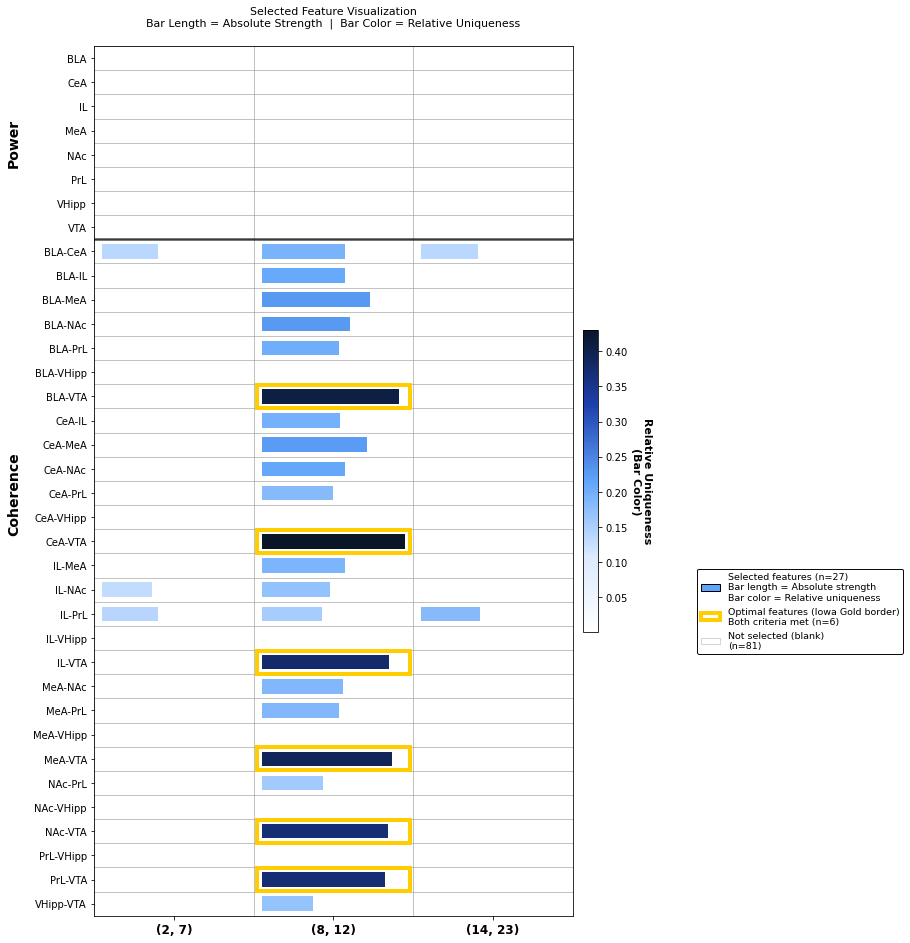

Bar heatmap saved : LickGroomEF_3band_bar_heatmap.png  (6 optimal features)


In [6]:
abs_cut, rel_cut, both_cut, abs_full, rel_full = process_W_nmf_dual_filter(
    model.get_W_nmf(), full_dict,
    abs_cum_ratio=0.8, rel_val=0.3,
    verbose=False,
)
fig = create_bar_heatmap_selective(abs_full, abs_cut, rel_full, rel_cut, both_cut)
fig.savefig("LickGroomEF_3band_bar_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Bar heatmap saved : LickGroomEF_3band_bar_heatmap.png  "
      f"({(~both_cut.isna()).sum().sum()} optimal features)")


## Section 6. Validation on ELS group

In [7]:
els = validate_on_ELS(model, {"E mice (licking vs selfgroom pair)": test_e})
print(els.summary())


VALIDATION ON ELS GROUP
  E mice (licking vs selfgroom pair): AUC = 0.6421 ± 0.0783  (n=4 mice)   Wilcoxon p = 0.125  n.s.


## Section 8. Additional backprojections (additional backprojection)

In [8]:
PUP_RETRIEVAL_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_All/Combined/P4_pup_retrieval_detail.pkl"

pup_retrieval_export(
    model,
    pup_retrieval_data_file=PUP_RETRIEVAL_DATA_FILE,
    c_mouse_ids=["C6ELS9", "C7ELS11"] + C_MOUSE_IDS,  # add back C7ELS11 + C6ELS9 for the pup-retrieval workbook
    e_mouse_ids=E_MOUSE_IDS,
    output_xlsx="LickGroom_pups_3band.xlsx",
)


  Sara pup retrieval written: LickGroom_pups_3band.xlsx  (8 mice, Individual + Summary sheets)
